<a href="https://colab.research.google.com/github/samiraghafarigousheh-sys/PyBuildingEnergy_AIBteam_AU/blob/main/comparison_pybuildingenergy_vs_pybuildingenergyau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Original pyBuildingEnergy — official PyPI release
!pip install -q pybuildingenergy

# Modified engine — Sarthak790's AIB fork (cloned, not installed, so we can pick its
# source path explicitly when we want to use it)
import os
FORK_DIR = "/content/pybuildingenergy_AIB_fork"
if not os.path.exists(FORK_DIR):
    !git clone -q https://github.com/Sarthak790/pybuildinenergy_AIB.git {FORK_DIR}



import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WEATHER_SOURCE = "pvgis"   # same weather source used for BOTH engines below


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 63.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.4/98.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.0/633.0 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 96.7 MB/s eta 0:00:00
   ━━━━━

In [2]:
def build_bui():
    """Returns a fresh copy of the Apt 305 building dictionary (no shared state)."""

    # --- Construction U-values & thermal capacity — Australian BCA 2006 minimum-spec ---
    U_EXT_WALL  = 1.00   # brick veneer / precast w/ R1.0 insulation
    U_INT_WALL  = 2.50   # concrete block + plasterboard, no insulation
    U_INT_SLAB  = 1.80   # 200 mm concrete intermediate floor
    U_WINDOW    = 5.40   # aluminium-frame single glazing
    G_WINDOW    = 0.65   # SHGC of clear single glazing

    ABS_EXT_WALL = 0.75  # dark red brick
    ABS_INT      = 0.0

    C_EXT_WALL = 450_000   # heavy concrete external wall, J/m2K
    C_INT_WALL = 330_000   # concrete-block partition
    C_INT_SLAB = 480_000   # 200 mm concrete slab
    C_WINDOW   = 0

    # --- Geometry ---
    LEN_NS  = 5.0   # N-S length, m (west facade width, along Barry St)
    LEN_EW  = 4.0   # E-W depth, m
    HEIGHT  = 2.7   # ceiling height, m

    FLOOR_AREA = LEN_NS * LEN_EW
    VOLUME     = FLOOR_AREA * HEIGHT

    A_WEST_GROSS  = LEN_NS * HEIGHT
    A_EAST_GROSS  = LEN_NS * HEIGHT
    A_NORTH_GROSS = LEN_EW * HEIGHT
    A_SOUTH_GROSS = LEN_EW * HEIGHT

    WIN_WIDTH_FIXED,    WIN_HEIGHT_FIXED    = 0.9, 0.9
    WIN_WIDTH_OPERABLE, WIN_HEIGHT_OPERABLE = 0.9, 0.9
    A_WINDOW_FIXED    = WIN_WIDTH_FIXED * WIN_HEIGHT_FIXED
    A_WINDOW_OPERABLE = WIN_WIDTH_OPERABLE * WIN_HEIGHT_OPERABLE
    A_WINDOW_TOTAL    = A_WINDOW_FIXED + A_WINDOW_OPERABLE
    A_WEST_OPAQUE     = A_WEST_GROSS - A_WINDOW_TOTAL

    bui = {
        "building": {
            "name": "Apt_305_50_Barry_St_Carlton",
            "azimuth_relative_to_true_north": 0,
            "latitude":  -37.800,
            "longitude": 144.968,
            "exposed_perimeter": 0,
            "height": HEIGHT,
            "wall_thickness": 0.20,
            "n_floors": 1,
            "building_type_class": "Residential_apartment",
            "adj_zones_present": True,
            "number_adj_zone": 5,
            "net_floor_area": FLOOR_AREA,
            "construction_class": "class_iii",
            "construction_year": "2006-today",
            "country": "Australia",
        },
        "adjacent_zones": [
            {
                "name": "apt_above",
                "orientation_zone": {"azimuth": 270.0},
                "area_facade_elements": np.array([A_WEST_GROSS, A_NORTH_GROSS, A_EAST_GROSS, A_SOUTH_GROSS, FLOOR_AREA, FLOOR_AREA]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_EXT_WALL, U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_SLAB, U_INT_SLAB]),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": VOLUME,
                "building_type_class": "Residential_apartment",
                "a_use": FLOOR_AREA,
            },
            {
                "name": "apt_below",
                "orientation_zone": {"azimuth": 270.0},
                "area_facade_elements": np.array([A_WEST_GROSS, A_NORTH_GROSS, A_EAST_GROSS, A_SOUTH_GROSS, FLOOR_AREA, FLOOR_AREA]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_EXT_WALL, U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_SLAB, U_INT_SLAB]),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": VOLUME,
                "building_type_class": "Residential_apartment",
                "a_use": FLOOR_AREA,
            },
            {
                "name": "apt_north",
                "orientation_zone": {"azimuth": 0.0},
                "area_facade_elements": np.array([A_WEST_GROSS, A_NORTH_GROSS, A_EAST_GROSS, A_SOUTH_GROSS, FLOOR_AREA, FLOOR_AREA]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_SLAB, U_INT_SLAB]),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": VOLUME,
                "building_type_class": "Residential_apartment",
                "a_use": FLOOR_AREA,
            },
            {
                "name": "apt_south",
                "orientation_zone": {"azimuth": 180.0},
                "area_facade_elements": np.array([A_WEST_GROSS, A_NORTH_GROSS, A_EAST_GROSS, A_SOUTH_GROSS, FLOOR_AREA, FLOOR_AREA]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_WALL, U_INT_SLAB, U_INT_SLAB]),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": VOLUME,
                "building_type_class": "Residential_apartment",
                "a_use": FLOOR_AREA,
            },
            {
                "name": "corridor",
                "orientation_zone": {"azimuth": 90.0},
                "area_facade_elements": np.array([81.0, 5.4, 81.0, 5.4, 60.0, 60.0]),
                "typology_elements": ["OP", "OP", "OP", "OP", "OP", "OP"],
                "transmittance_U_elements": np.array([U_INT_WALL] * 6),
                "orientation_elements": np.array(["WV", "NV", "EV", "SV", "HOR", "HOR"]),
                "volume": 162.0,
                "building_type_class": "Residential_apartment",
                "a_use": 60.0,
            },
        ],
        "building_surface": [
            {
                "name": "West exterior wall (opaque)", "type": "opaque", "area": A_WEST_OPAQUE,
                "sky_view_factor": 0.5, "u_value": U_EXT_WALL, "solar_absorptance": ABS_EXT_WALL,
                "thermal_capacity": C_EXT_WALL, "orientation": {"azimuth": 270.0, "tilt": 90.0},
                "name_adj_zone": None, "height": HEIGHT, "length": LEN_NS,
            },
            {
                "name": "North wall to Apt 306", "type": "opaque", "area": A_NORTH_GROSS,
                "sky_view_factor": 0.0, "u_value": U_INT_WALL, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_WALL, "orientation": {"azimuth": 0.0, "tilt": 90.0},
                "name_adj_zone": "apt_north", "height": HEIGHT, "length": LEN_EW,
            },
            {
                "name": "South wall to Apt 304", "type": "opaque", "area": A_SOUTH_GROSS,
                "sky_view_factor": 0.0, "u_value": U_INT_WALL, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_WALL, "orientation": {"azimuth": 180.0, "tilt": 90.0},
                "name_adj_zone": "apt_south", "height": HEIGHT, "length": LEN_EW,
            },
            {
                "name": "East wall to corridor", "type": "opaque", "area": A_EAST_GROSS,
                "sky_view_factor": 0.0, "u_value": U_INT_WALL, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_WALL, "orientation": {"azimuth": 90.0, "tilt": 90.0},
                "name_adj_zone": "corridor", "height": HEIGHT, "length": LEN_NS,
            },
            {
                "name": "Floor to Apt 205", "type": "opaque", "area": FLOOR_AREA,
                "sky_view_factor": 0.0, "u_value": U_INT_SLAB, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_SLAB, "orientation": {"azimuth": 0.0, "tilt": 0.0},
                "name_adj_zone": "apt_below", "height": LEN_NS, "length": LEN_EW,
            },
            {
                "name": "Ceiling to Apt 405", "type": "opaque", "area": FLOOR_AREA,
                "sky_view_factor": 0.0, "u_value": U_INT_SLAB, "solar_absorptance": ABS_INT,
                "thermal_capacity": C_INT_SLAB, "orientation": {"azimuth": 0.0, "tilt": 0.0},
                "name_adj_zone": "apt_above", "height": LEN_NS, "length": LEN_EW,
            },
            {
                "name": "West window — fixed", "type": "transparent", "area": A_WINDOW_FIXED,
                "sky_view_factor": 0.5, "u_value": U_WINDOW, "solar_absorptance": 0.5,
                "thermal_capacity": C_WINDOW, "orientation": {"azimuth": 270.0, "tilt": 90.0},
                "name_adj_zone": None, "height": WIN_HEIGHT_FIXED, "g_value": G_WINDOW,
                "width": WIN_WIDTH_FIXED, "parapet": 1.0, "shading": True,
                "shading_type": "horizontal_overhang", "width_or_distance_of_shading_elements": 0.05,
                "overhang_proprieties": {"width_of_horizontal_overhangs": 0.25},
            },
            {
                "name": "West window — operable", "type": "transparent", "area": A_WINDOW_OPERABLE,
                "sky_view_factor": 0.5, "u_value": U_WINDOW, "solar_absorptance": 0.5,
                "thermal_capacity": C_WINDOW, "orientation": {"azimuth": 270.0, "tilt": 90.0},
                "name_adj_zone": None, "height": WIN_HEIGHT_OPERABLE, "g_value": G_WINDOW,
                "width": WIN_WIDTH_OPERABLE, "parapet": 1.0, "shading": True,
                "shading_type": "horizontal_overhang", "width_or_distance_of_shading_elements": 0.05,
                "overhang_proprieties": {"width_of_horizontal_overhangs": 0.25},
            },
        ],
        "units": {
            "area": "m\u00b2", "u_value": "W/m\u00b2K", "thermal_capacity": "J/m\u00b2K",
            "azimuth": "degrees (0=N, 90=E, 180=S, 270=W)", "tilt": "degrees (0=horizontal, 90=vertical)",
            "internal_gain": "W/m\u00b2", "HVAC_profile": "0: off, 1: on",
        },
        "building_parameters": {
            "temperature_setpoints": {
                # Fixed setpoints, as used in copy_of_pybuildingenergy_my_house.ipynb.
                # The modified-engine cell overrides these with NCC zone-derived setpoints.
                "heating_setpoint": 18.0,
                "heating_setback":  15.0,
                "cooling_setpoint": 26.0,
                "cooling_setback":  28.0,
                "units": "\u00b0C",
            },
            "system_capacities": {
                "heating_capacity": 10_000_000.0,
                "cooling_capacity": 10_000_000.0,
                "units": "W",
            },
            "ventilation": {
                "ventilation_type": "occupancy",
                "flow_rate_per_person": 2.0,
                "units": "l/(s m\u00b2)",
                "custom_heat_transfer_coefficient_ventilation": None,
            },
            "internal_gains": [
                {
                    "name": "occupants", "full_load": 8.0,
                    "weekday": [1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.4,0.5,0.5,0.5,0.4,0.5,0.5,0.5,0.5,0.5,1.0,1.0,1.0,1.0],
                    "weekend": [1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.8,0.7,0.7,0.7,0.7,0.5,0.5,0.7,0.8,1.0,1.0,1.0,1.0,1.0,1.0],
                },
                {
                    "name": "appliances", "full_load": 25.0,
                    "weekday": [0.1,0.1,0.1,0.1,0.1,0.1,0.2,0.3,0.2,0.2,0.2,0.2,0.3,0.2,0.2,0.2,0.2,0.3,0.3,0.4,1.0,0.6,0.4,0.2],
                    "weekend": [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.2,0.3,0.4,0.3,0.3,0.4,0.3,0.3,0.3,0.3,0.4,0.4,0.5,1.0,0.6,0.4,0.2],
                },
                {
                    "name": "lighting", "full_load": 3.0,
                    "weekday": [0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.5,0.8,0.8,0.8,0.7,0.4,0.1],
                    "weekend": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.3,0.3,0.2,0.2,0.2,0.2,0.2,0.2,0.3,0.5,0.8,0.8,0.8,0.7,0.4,0.1],
                },
            ],
            "construction": {
                "wall_thickness": 0.20,
                "thermal_bridges": 1.5,
                "units": "m (thickness), W/mK (thermal bridges)",
            },
            "climate_parameters": {"coldest_month": 7, "units": "1-12 (January-December)"},
            "heating_profile": {
                "weekday": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0],
                "weekend": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0],
            },
            "cooling_profile": {
                "weekday": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0],
                "weekend": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0],
            },
            "ventilation_profile": {
                "weekday": [1.0] * 24,
                "weekend": [1.0] * 24,
            },
        },
    }
    return bui

FLOOR_AREA = build_bui()["building"]["net_floor_area"]
print(f"Floor area: {FLOOR_AREA} m2")


Floor area: 20.0 m2


In [3]:
from pybuildingenergy.source.check_input import sanitize_and_validate_BUI as orig_sanitize
from pybuildingenergy.source.utils import ISO52016 as OrigISO52016

bui_original = build_bui()
bui_original_fixed, report_original = orig_sanitize(bui_original, fix=True)

print("=== Validation (original engine) ===")
for r in report_original:
    fix_tag = " (fix applied)" if r["fix_applied"] else ""
    print(f"  [{r['level']}] {r['path']}: {r['msg']}{fix_tag}")

errors_original = [r for r in report_original if r["level"] == "ERROR"]
if errors_original:
    raise ValueError("Building input invalid for the original engine — fix errors above.")



print(f"=== Running ORIGINAL engine (weather: {WEATHER_SOURCE}) ===")
# The PyPI release returns a 2-tuple (hourly_sim, annual_results_df); the fork's engine
# (used below) returns a 3-tuple that also includes Sankey flow data. Handle both.
_orig_out = OrigISO52016.Temperature_and_Energy_needs_calculation(
    bui_original_fixed, weather_source=WEATHER_SOURCE
)
if len(_orig_out) == 3:
    hourly_original, annual_original, sankey_original = _orig_out
else:
    hourly_original, annual_original = _orig_out
    sankey_original = {}

Q_HC_original = hourly_original["Q_HC"]
heating_kWh_original = Q_HC_original[Q_HC_original > 0].sum() / 1000.0
cooling_kWh_original = -Q_HC_original[Q_HC_original < 0].sum() / 1000.0

print(f"\nORIGINAL engine — Heating need: {heating_kWh_original:8.1f} kWh/yr "
      f"({heating_kWh_original/FLOOR_AREA:5.1f} kWh/m2/yr)")
print(f"ORIGINAL engine — Cooling need: {cooling_kWh_original:8.1f} kWh/yr "
      f"({cooling_kWh_original/FLOOR_AREA:5.1f} kWh/m2/yr)")

=== Validation (original engine) ===
  [WARN] building.exposed_perimeter: exposed_perimeter era 0; impostato a 1.0 (fix applied)
  [WARN] building_surface[6].parapet: parapet fuori range; clippato a 0.9 (fix applied)
  [WARN] building_surface[7].parapet: parapet fuori range; clippato a 0.9 (fix applied)
=== Running ORIGINAL engine (weather: pvgis) ===


  0%|          | 12/9504 [00:00<02:47, 56.53it/s]

[t=0] T_op0=28.00  Phi_HC=-106.9  int_gains=660.1  Phi_solar=0.0  H_ve_nat=12.112
[t=1] T_op0=28.00  Phi_HC=-456.9  int_gains=660.1  Phi_solar=0.0  H_ve_nat=12.112
[t=2] T_op0=28.00  Phi_HC=-460.6  int_gains=660.1  Phi_solar=0.0  H_ve_nat=12.112
[t=3] T_op0=28.00  Phi_HC=-479.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=12.112
[t=4] T_op0=28.00  Phi_HC=-457.3  int_gains=660.1  Phi_solar=0.0  H_ve_nat=12.112
[t=5] T_op0=28.00  Phi_HC=-440.8  int_gains=660.1  Phi_solar=0.0  H_ve_nat=12.112


100%|██████████| 9504/9504 [02:27<00:00, 64.57it/s]


SANKEY CHECK  inputs=6900542.9  outputs+storage=5651725.7  residual=1248817.3 Wh (18.097%)



ORIGINAL engine — Heating need:      0.0 kWh/yr (  0.0 kWh/m2/yr)
ORIGINAL engine — Cooling need:   2572.0 kWh/yr (128.6 kWh/m2/yr)


In [5]:
# Drop the PyPI package's cached modules so "pybuildingenergy" re-resolves to the fork
for mod_name in list(sys.modules):
    if mod_name == "pybuildingenergy" or mod_name.startswith("pybuildingenergy."):
        del sys.modules[mod_name]

FORK_SRC   = f"{FORK_DIR}/pyBuildingEnergy/src"
FORK_TESTS = f"{FORK_DIR}/pyBuildingEnergy/tests"
for p in (FORK_SRC, FORK_TESTS):
    if p not in sys.path:
        sys.path.insert(0, p)

from pybuildingenergy.source.check_input import sanitize_and_validate_BUI as mod_sanitize
from pybuildingenergy.source.utils import ISO52016 as ModISO52016
from climate_setpoints import get_ncc_setpoints, apply_setpoints_to_building

print("Modified engine imported from:", ModISO52016.__module__)



bui_modified = build_bui()

# This is the core behavioural change in the fork: setpoints are derived from the
# building's NCC 2022 climate zone instead of being fixed by the user.
ncc_setpoints = get_ncc_setpoints(
    lat=bui_modified["building"]["latitude"],
    lon=bui_modified["building"]["longitude"],
)
bui_modified = apply_setpoints_to_building(bui_modified, ncc_setpoints)

print("=== NCC setpoints applied (modified engine) ===")
print(f"  NCC zone        : {ncc_setpoints['ncc_zone']}")
print(f"  Heating setpoint: {ncc_setpoints['heating_setpoint']} C")
print(f"  Cooling (bedroom): {ncc_setpoints['cooling_setpoint_bedroom']} C")
print(f"  Cooling (living) : {ncc_setpoints['cooling_setpoint_living']} C")
print(f"  Heating setback  : {ncc_setpoints['heating_setback']} C")
print(f"  Cooling setback  : {ncc_setpoints['cooling_setback']} C")



bui_modified_fixed, report_modified = mod_sanitize(bui_modified, fix=True)

print("=== Validation (modified engine) ===")
for r in report_modified:
    fix_tag = " (fix applied)" if r["fix_applied"] else ""
    print(f"  [{r['level']}] {r['path']}: {r['msg']}{fix_tag}")

errors_modified = [r for r in report_modified if r["level"] == "ERROR"]
if errors_modified:
    raise ValueError("Building input invalid for the modified engine — fix errors above.")

Modified engine imported from: pybuildingenergy.source.utils
  Reverse geocoding coordinates: (-37.8, 144.968) ...
  Resolved to: Clocktower, Carlton Clock Tower Complex, Carlton, Victoria, 3053, Australia
  Postcode: 3053
=== NCC setpoints applied (modified engine) ===
  NCC zone        : 6
  Heating setpoint: 20.0 C
  Cooling (bedroom): 24.0 C
  Cooling (living) : 26.0 C
  Heating setback  : 17.0 C
  Cooling setback  : 27.0 C
=== Validation (modified engine) ===
  [WARN] building.exposed_perimeter: exposed_perimeter was 0; set to 1.0 (fix applied)
  [WARN] building_surface[6].parapet: parapet out of range; clipped to 0.9 (fix applied)
  [WARN] building_surface[7].parapet: parapet out of range; clipped to 0.9 (fix applied)


In [6]:
print(f"=== Running MODIFIED engine (weather: {WEATHER_SOURCE}) ===")
_mod_out = ModISO52016.Temperature_and_Energy_needs_calculation(
    bui_modified_fixed, weather_source=WEATHER_SOURCE
)
if len(_mod_out) == 3:
    hourly_modified, annual_modified, sankey_modified = _mod_out
else:
    hourly_modified, annual_modified = _mod_out
    sankey_modified = {}

Q_HC_modified = hourly_modified["Q_HC"]
heating_kWh_modified = Q_HC_modified[Q_HC_modified > 0].sum() / 1000.0
cooling_kWh_modified = -Q_HC_modified[Q_HC_modified < 0].sum() / 1000.0

print(f"\nMODIFIED engine — Heating need: {heating_kWh_modified:8.1f} kWh/yr "
      f"({heating_kWh_modified/FLOOR_AREA:5.1f} kWh/m2/yr)")
print(f"MODIFIED engine — Cooling need: {cooling_kWh_modified:8.1f} kWh/yr "
      f"({cooling_kWh_modified/FLOOR_AREA:5.1f} kWh/m2/yr)")


=== Running MODIFIED engine (weather: pvgis) ===


  8%|▊         | 1/13 [00:06<01:18,  6.55s/it, Info=Inizailization 1]

[ISO 13370] Converted Basement Wall 'North wall to Apt 306': Raw U=2.50 -> Soil-Adjusted U=0.776
[ISO 13370] Converted Basement Wall 'South wall to Apt 304': Raw U=2.50 -> Soil-Adjusted U=0.776
[ISO 13370] Converted Basement Wall 'East wall to corridor': Raw U=2.50 -> Soil-Adjusted U=0.776


  0%|          | 7/9504 [00:00<02:26, 64.83it/s]

[t=0] T_op0=25.92  Phi_HC=0.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449
[t=1] T_op0=27.00  Phi_HC=-109.1  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449
[t=2] T_op0=27.00  Phi_HC=-186.8  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449
[t=3] T_op0=27.00  Phi_HC=-224.0  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449
[t=4] T_op0=27.00  Phi_HC=-183.2  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449
[t=5] T_op0=27.00  Phi_HC=-147.4  int_gains=660.1  Phi_solar=0.0  H_ve_nat=48.449


100%|██████████| 9504/9504 [01:59<00:00, 79.78it/s]

SANKEY CHECK  inputs=7254116.6  outputs+storage=5187016.1  residual=2067100.6 Wh (28.496%)

MODIFIED engine — Heating need:    157.8 kWh/yr (  7.9 kWh/m2/yr)
MODIFIED engine — Cooling need:   1277.6 kWh/yr ( 63.9 kWh/m2/yr)


In [8]:
comparison_df = pd.DataFrame([
    {
        "engine": "Original pyBuildingEnergy (PyPI)",
        "setpoints": "Fixed 18C / 26C",
        "heating_kWh": round(heating_kWh_original, 1),
        "cooling_kWh": round(cooling_kWh_original, 1),
        "heating_kWh_m2": round(heating_kWh_original / FLOOR_AREA, 1),
        "cooling_kWh_m2": round(cooling_kWh_original / FLOOR_AREA, 1),
    },
    {
        "engine": "Modified AIB fork",
        "setpoints": f"NCC zone {ncc_setpoints['ncc_zone']} "
                     f"({ncc_setpoints['heating_setpoint']}C / {ncc_setpoints['cooling_setpoint_living']}C)",
        "heating_kWh": round(heating_kWh_modified, 1),
        "cooling_kWh": round(cooling_kWh_modified, 1),
        "heating_kWh_m2": round(heating_kWh_modified / FLOOR_AREA, 1),
        "cooling_kWh_m2": round(cooling_kWh_modified / FLOOR_AREA, 1),
    },
])
comparison_df


,engine,setpoints,heating_kWh,cooling_kWh,heating_kWh_m2,cooling_kWh_m2
0,Original pyBuildingEnergy (PyPI),Fixed 18C / 26C,0.0,2572.0,0.0,128.6
1,Modified AIB fork,NCC zone 6 (20.0C / 26.0C),157.8,1277.6,7.9,63.9


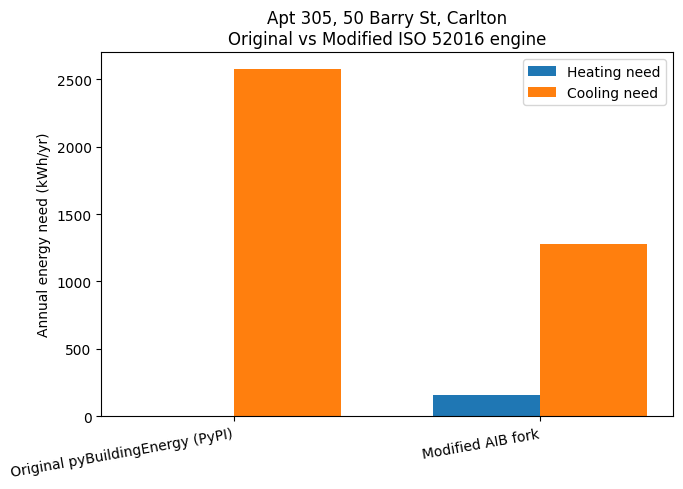

Saved: /content/engine_comparison_apt305.csv


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width / 2, comparison_df["heating_kWh"], width, label="Heating need")
ax.bar(x + width / 2, comparison_df["cooling_kWh"], width, label="Cooling need")

ax.set_xticks(x)
ax.set_xticklabels(comparison_df["engine"], rotation=10, ha="right")
ax.set_ylabel("Annual energy need (kWh/yr)")
ax.set_title("Apt 305, 50 Barry St, Carlton\nOriginal vs Modified ISO 52016 engine")
ax.legend()
plt.tight_layout()
plt.show()



OUTPUT_PATH = "/content/engine_comparison_apt305.csv"
comparison_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")


## 6. What exactly is different between the two engines?

Summary of every concrete difference observed between the official PyPI `pybuildingenergy`
engine and the `Sarthak790/pybuildinenergy_AIB` fork, based on running both against the
*identical* Apt 305 building dictionary and weather source above.


In [ ]:
differences = [
    {
        "area": "Heating/cooling setpoints",
        "original_engine": "Fixed values supplied by the user (18C heating / 26C cooling, "
                            "from the BUI dictionary's temperature_setpoints block).",
        "modified_engine": "Derived automatically from the building's NCC 2022 climate zone "
                            "via get_ncc_setpoints()/apply_setpoints_to_building() — here, "
                            f"zone {ncc_setpoints['ncc_zone']} -> "
                            f"{ncc_setpoints['heating_setpoint']}C heating / "
                            f"{ncc_setpoints['cooling_setpoint_living']}C cooling (living areas), "
                            f"{ncc_setpoints['cooling_setpoint_bedroom']}C (bedroom).",
    },
    {
        "area": "Interior wall U-values (ISO 13370 ground coupling)",
        "original_engine": "Interior partition walls (sky_view_factor = 0, e.g. the walls "
                            "to Apt 306 / Apt 304 / the corridor) keep the U-value exactly "
                            "as supplied: 2.50 W/m2K.",
        "modified_engine": "Auto-detects sky_view_factor = 0 walls as 'basement walls' and "
                            "applies an ISO 13370 soil-adjustment, silently rewriting their "
                            "U-value from 2.50 to 0.776 W/m2K before the simulation runs "
                            "(see the '[ISO 13370] Converted Basement Wall ...' log lines "
                            "above). This was NOT requested by the building dictionary — it "
                            "is an automatic engine-side reinterpretation of any zero-sky-view "
                            "opaque surface as ground-adjacent.",
    },
    {
        "area": "Weather source used here",
        "original_engine": f"PVGIS TMY ({WEATHER_SOURCE}) — identical to modified engine in "
                            "this notebook for a fair comparison.",
        "modified_engine": f"PVGIS TMY ({WEATHER_SOURCE}) here; the fork's own test instead "
                            "hardcodes a local Sydney EPW file path by default.",
    },
    {
        "area": "Schedule injection",
        "original_engine": "Occupant/appliance/lighting schedules are read only from the "
                            "BUI dictionary's building_parameters.internal_gains block.",
        "modified_engine": "Same dictionary-based schedules work, but "
                            "Temperature_and_Energy_needs_calculation also accepts explicit "
                            "occupants_schedule_workdays/weekend, appliances_schedule_*, and "
                            "lighting_schedule_* keyword arguments that override the "
                            "dictionary values directly (used in the fork's sample_test.py).",
    },
    {
        "area": "Latent heat / humidity",
        "original_engine": "hourly_sim has no latent-heat or moisture columns — sensible "
                            "heating/cooling load (Q_HC) only.",
        "modified_engine": "hourly_sim additionally includes Q_Latent (latent load, Wh) and "
                            "x_air_in (indoor moisture content) columns — a humidity balance "
                            "the original engine does not compute.",
    },
    {
        "area": "Domestic hot water (DHW)",
        "original_engine": "Not part of Temperature_and_Energy_needs_calculation; would "
                            "need to be added manually with Volume_and_energy_DHW_calculation.",
        "modified_engine": "Same DHW function is available and is combined with Q_H/Q_C/"
                            "Q_Latent into a single annual total in the fork's test.",
    },
    {
        "area": "Return signature",
        "original_engine": "Returns a 2-tuple: (hourly_sim, annual_results_df).",
        "modified_engine": "Returns a 3-tuple: (hourly_sim, annual_results_df, sankey_data).",
    },
    {
        "area": "Validation messages (sanitize_and_validate_BUI)",
        "original_engine": "Warning text is partly in Italian, "
                            "e.g. \"exposed_perimeter era 0; impostato a 1.0\".",
        "modified_engine": "Equivalent warnings are in English, "
                            "e.g. \"exposed_perimeter was 0; set to 1.0\".",
    },
]

diff_df = pd.DataFrame(differences)
pd.set_option("display.max_colwidth", 100)
diff_df


---

## 7. EnergyPlus — Full Heat-Balance Simulation

> **Methodology note:** EnergyPlus uses a **full heat-balance engine** (CTF conduction + combined radiative–convective surface balances), whereas both ISO 52016 engines above use the **simplified 5R1C RC-network** from ISO 52016-1. Results will differ even with identical inputs — that methodological gap is itself a key finding of this comparison.

| Parameter | Choice made |
|---|---|
| Weather | PVGIS TMY for lat=−37.800, lon=144.968, downloaded as EPW (same source as ISO 52016 runs) |
| Adjacent zones | All 5 neighbours fixed at **20 °C** year-round (conditioned-neighbour approximation) |
| Setpoints | Heating **18 °C** / Cooling **26 °C** — same as the original engine |
| Thermal capacity | `Material:NoMass` used; mass is absent (mirroring ISO 52016-1 steady-state RC intent) |
| HVAC | `ZoneHVAC:IdealLoadsAirSystem` — unlimited capacity, matches pyBuildingEnergy assumption |
| EnergyPlus version | 24.1.0 (downloaded on first run, ~150 MB) |

In [ ]:
# ── EnergyPlus 24.1.0 — install via tar.gz (no interactive prompt) ───────────
import os, subprocess, sys, requests

EP_VERSION = "24.1.0"
EP_SHA     = "9d7789a3ac"
EP_DIR     = "/opt/energyplus"

if not os.path.exists(EP_DIR):
    tar_name = f"EnergyPlus-{EP_VERSION}-{EP_SHA}-Linux-Ubuntu22.04-x86_64.tar.gz"
    tar_url  = (
        f"https://github.com/NREL/EnergyPlus/releases/download/"
        f"v{EP_VERSION}/{tar_name}"
    )
    tar_path = f"/tmp/{tar_name}"

    print(f"Downloading EnergyPlus {EP_VERSION} (tar.gz) …")
    subprocess.run(["wget", "-q", "--show-progress", "-O", tar_path, tar_url], check=True)

    print("Extracting …")
    os.makedirs(EP_DIR, exist_ok=True)
    # --strip-components=1 removes the top-level folder inside the archive
    subprocess.run(
        ["tar", "-xzf", tar_path, "--strip-components=1", "-C", EP_DIR],
        check=True,
    )
    os.remove(tar_path)
    print(f"Installed → {EP_DIR}")
else:
    print(f"EnergyPlus already at {EP_DIR}")

# Confirm the binary exists before continuing
ep_bin = os.path.join(EP_DIR, "energyplus")
assert os.path.exists(ep_bin), f"energyplus binary not found in {EP_DIR}"
print(f"Binary OK: {ep_bin}")

if EP_DIR not in sys.path:
    sys.path.insert(0, EP_DIR)

# ── PVGIS TMY → EPW  (same weather source as the ISO 52016 simulations) ──────
EPW_PATH = "/content/Melbourne_PVGIS_TMY.epw"
if not os.path.exists(EPW_PATH):
    print("Downloading PVGIS TMY as EPW …")
    pvgis_url = (
        "https://re.jrc.ec.europa.eu/api/v5_2/tmy"
        "?lat=-37.800&lon=144.968&outputformat=epw"
    )
    r = requests.get(pvgis_url, timeout=120)
    r.raise_for_status()
    with open(EPW_PATH, "wb") as f:
        f.write(r.content)
    print(f"Saved EPW → {EPW_PATH}  ({len(r.content)//1024} kB)")
else:
    print(f"EPW already at {EPW_PATH}")

with open(EPW_PATH) as f:
    first = f.readline().strip()
print(f"EPW header: {first[:80]}")

In [ ]:
def _sched_frac(name, wd, we):
    rows = ["Schedule:Compact,\n  {},\n  Fraction,\n  Through: 12/31,".format(name),
            "  For: Weekdays,"]
    for h, v in enumerate(wd, 1):
        rows.append("  Until: {:02d}:00,{},".format(h, v))
    rows.append("  For: AllOtherDays,")   # covers weekends + all design-day types
    for h, v in enumerate(we, 1):
        rows.append("  Until: {:02d}:00,{}{}".format(h, v, "," if h < 24 else ";"))
    return "\n".join(rows)

def _sched_temp(name, wd, we):
    rows = ["Schedule:Compact,\n  {},\n  Temperature,\n  Through: 12/31,".format(name),
            "  For: Weekdays,"]
    for h, v in enumerate(wd, 1):
        rows.append("  Until: {:02d}:00,{},".format(h, v))
    rows.append("  For: AllOtherDays,")
    for h, v in enumerate(we, 1):
        rows.append("  Until: {:02d}:00,{}{}".format(h, v, "," if h < 24 else ";"))
    return "\n".join(rows)

def build_ep_idf(heating_sp=18.0, cooling_sp=26.0, heating_sb=15.0, cooling_sb=28.0):
    """
    EnergyPlus IDF for Apt 305 mirroring build_bui() inputs.
    Material:NoMass R-values back-calculated to match assembly U-values.
    5 neighbour surfaces fixed at 20 C via OtherSideCoefficients.
    ZoneHVAC:IdealLoadsAirSystem (unlimited capacity).
    Ventilation: 0.002 m3/s/m2.
    """
    bui  = build_bui()
    bp   = bui["building_parameters"]
    ig   = {g["name"]: g for g in bp["internal_gains"]}

    occ_wd = ig["occupants"]["weekday"];  occ_we = ig["occupants"]["weekend"]
    app_wd = ig["appliances"]["weekday"]; app_we = ig["appliances"]["weekend"]
    lit_wd = ig["lighting"]["weekday"];   lit_we = ig["lighting"]["weekend"]
    h_wd = bp["heating_profile"]["weekday"]; h_we = bp["heating_profile"]["weekend"]
    c_wd = bp["cooling_profile"]["weekday"]; c_we = bp["cooling_profile"]["weekend"]

    hsp_wd = [heating_sp if v > 0 else heating_sb for v in h_wd]
    hsp_we = [heating_sp if v > 0 else heating_sb for v in h_we]
    csp_wd = [cooling_sp if v > 0 else cooling_sb for v in c_wd]
    csp_we = [cooling_sp if v > 0 else cooling_sb for v in c_we]

    R_ext = round(max(0.001, 1/1.00 - 0.13 - 0.04), 4)
    R_int = round(max(0.001, 1/2.50 - 0.13 - 0.13), 4)
    R_slb = round(max(0.001, 1/1.80 - 0.13 - 0.13), 4)
    LEN_NS = 5.0; LEN_EW = 4.0; H = 2.7

    schedules = "\n\n".join([
        _sched_frac("Occ_Sched",  occ_wd, occ_we),
        _sched_frac("App_Sched",  app_wd, app_we),
        _sched_frac("Lit_Sched",  lit_wd, lit_we),
        _sched_temp("Heat_SP",    hsp_wd, hsp_we),
        _sched_temp("Cool_SP",    csp_wd, csp_we),
        "Schedule:Compact,\n  Always1,\n  Fraction,\n  Through: 12/31,"
        "\n  For: AllDays,\n  Until: 24:00,1.0;",
        "Schedule:Compact,\n  Activity_W,\n  Any Number,\n  Through: 12/31,"
        "\n  For: AllDays,\n  Until: 24:00,160.0;",
    ])

    parts = []

    parts.append(
        "  Version, 24.1;\n\n"
        "  SimulationControl, Yes, No, No, No, Yes;\n\n"
        "  Building,\n"
        "    Apt_305_50_Barry_St_Carlton,\n"
        "    0.0, Suburbs, 0.04, 0.004,\n"
        "    FullInteriorAndExterior, 25, 6;\n\n"
        "  Timestep, 6;\n\n"
        "  GlobalGeometryRules,\n"
        "    UpperLeftCorner, CounterClockWise, World;\n\n"
        "  Site:Location,\n"
        "    Melbourne_VIC_AUS,\n"
        "    -37.800, 144.968, 10.0, 31.0;\n\n"
        "  RunPeriod,\n"
        "    FullYear,\n"
        "    1, 1, , 12, 31, ,\n"
        "    Sunday, Yes, Yes, No, Yes, Yes;\n\n"
        "  ScheduleTypeLimits, Fraction, 0.0, 1.0, Continuous, Dimensionless;\n"
        "  ScheduleTypeLimits, Temperature, -100, 200, Continuous, Temperature;\n"
        "  ScheduleTypeLimits, Any Number, -1e10, 1e10, Continuous;"
    )

    parts.append(schedules)

    parts.append(
        "  Zone, Apt305, 0.0, 0.0, 0.0, 0.0, 1, 1, {}, {}, {};".format(
            H, LEN_EW*LEN_NS*H, LEN_EW*LEN_NS)
    )

    parts.append(
        "  Material:NoMass, Mat_ExtWall, MediumRough,  {}, 0.9, 0.75, 0.75;\n"
        "  Material:NoMass, Mat_IntWall, MediumSmooth, {}, 0.9, 0.0,  0.0;\n"
        "  Material:NoMass, Mat_IntSlab, MediumSmooth, {}, 0.9, 0.0,  0.0;\n"
        "  WindowMaterial:SimpleGlazingSystem, Mat_Window, 5.40, 0.65;\n\n"
        "  Construction, Con_ExtWall, Mat_ExtWall;\n"
        "  Construction, Con_IntWall, Mat_IntWall;\n"
        "  Construction, Con_IntSlab, Mat_IntSlab;\n"
        "  Construction, Con_Window,  Mat_Window;".format(R_ext, R_int, R_slb)
    )

    parts.append(
        "  SurfaceProperty:OtherSideCoefficients,\n"
        "    OSC_Adj20C,\n"
        "    8.0,\n"
        "    20.0,\n"
        "    1.0, 0.0, 0.0, 0.0, 0.0;"
    )

    parts.append(
        "  BuildingSurface:Detailed,\n"
        "    WestWall, Wall, Con_ExtWall, Apt305, ,\n"
        "    Outdoors, , SunExposed, WindExposed, , 4,\n"
        "    0.0, {LN}, {H},\n"
        "    0.0, {LN}, 0.0,\n"
        "    0.0, 0.0, 0.0,\n"
        "    0.0, 0.0, {H};\n\n"
        "  BuildingSurface:Detailed,\n"
        "    NorthWall, Wall, Con_IntWall, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    {LE}, {LN}, {H},\n"
        "    {LE}, {LN}, 0.0,\n"
        "    0.0, {LN}, 0.0,\n"
        "    0.0, {LN}, {H};\n\n"
        "  BuildingSurface:Detailed,\n"
        "    EastWall, Wall, Con_IntWall, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    {LE}, 0.0, {H},\n"
        "    {LE}, 0.0, 0.0,\n"
        "    {LE}, {LN}, 0.0,\n"
        "    {LE}, {LN}, {H};\n\n"
        "  BuildingSurface:Detailed,\n"
        "    SouthWall, Wall, Con_IntWall, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    0.0, 0.0, {H},\n"
        "    0.0, 0.0, 0.0,\n"
        "    {LE}, 0.0, 0.0,\n"
        "    {LE}, 0.0, {H};\n\n"
        "  BuildingSurface:Detailed,\n"
        "    FloorSlab, Floor, Con_IntSlab, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    0.0, 0.0, 0.0,\n"
        "    0.0, {LN}, 0.0,\n"
        "    {LE}, {LN}, 0.0,\n"
        "    {LE}, 0.0, 0.0;\n\n"
        "  BuildingSurface:Detailed,\n"
        "    CeilingSlab, Ceiling, Con_IntSlab, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    0.0, 0.0, {H},\n"
        "    {LE}, 0.0, {H},\n"
        "    {LE}, {LN}, {H},\n"
        "    0.0, {LN}, {H};\n\n"
        "  FenestrationSurface:Detailed,\n"
        "    WestWin_Fixed, Window, Con_Window, WestWall, , , , 1.0, 4,\n"
        "    0.0, {y1h}, 1.9,  0.0, {y1h}, 1.0,\n"
        "    0.0, {y1l}, 1.0,  0.0, {y1l}, 1.9;\n\n"
        "  FenestrationSurface:Detailed,\n"
        "    WestWin_Operable, Window, Con_Window, WestWall, , , , 1.0, 4,\n"
        "    0.0, {y2h}, 1.9,  0.0, {y2h}, 1.0,\n"
        "    0.0, {y2l}, 1.0,  0.0, {y2l}, 1.9;".format(
            H=H, LN=LEN_NS, LE=LEN_EW,
            y1h=LEN_NS-1.0, y1l=LEN_NS-1.9,
            y2h=LEN_NS-2.5, y2l=LEN_NS-3.4,
        )
    )

    parts.append(
        # People: Method, LightingLevel(blank), PeoplePerArea, ZoneAreaPerPerson(blank),
        #         FracRadiant, SensibleHeatFrac(blank), ActivitySchedule
        "  People,\n"
        "    Apt305_People, Apt305, Occ_Sched,\n"
        "    People/Area, , 0.05, , 0.3, , Activity_W;\n\n"
        # ElectricEquipment: Method, DesignLevel(blank), W/Area, W/Person(blank),
        #   FracLatent, FracRadiant, FracLost
        "  ElectricEquipment,\n"
        "    Apt305_Appliances, Apt305, App_Sched,\n"
        "    Watts/Area, , 25.0, , 0.0, 0.5, 0.0;\n\n"
        # Lights: Method, LightingLevel(blank), W/Area, W/Person(blank),
        #   ReturnAirFrac, FracRadiant, FracVisible
        "  Lights,\n"
        "    Apt305_Lights, Apt305, Lit_Sched,\n"
        "    Watts/Area, , 3.0, , 0.0, 0.72, 0.18;"
    )

    parts.append(
        "  DesignSpecification:OutdoorAir,\n"
        "    Apt305_OA, Flow/Area, 0.002, , , , Always1;"
    )

    parts.append(
        "  ZoneHVAC:IdealLoadsAirSystem,\n"
        "    Apt305_IdealLoads, ,\n"
        "    Apt305_SupplyAir, Apt305_ExhaustAir, ,\n"
        "    50, 12, 0.010, 0.010,\n"
        "    NoLimit, , , NoLimit, , ,\n"
        "    , ,\n"
        "    ConstantSupplyHumidityRatio, ,\n"
        "    ConstantSupplyHumidityRatio,\n"
        "    Apt305_OA, , , , , , ;\n\n"
        "  ZoneHVAC:EquipmentList,\n"
        "    Apt305_EqpList,\n"
        "    SequentialLoad,\n"
        "    ZoneHVAC:IdealLoadsAirSystem, Apt305_IdealLoads, 1, 1;\n\n"
        "  ZoneHVAC:EquipmentConnections,\n"
        "    Apt305, Apt305_EqpList,\n"
        "    Apt305_SupplyAir, Apt305_ExhaustAir,\n"
        "    Apt305_ZoneAirNode;\n\n"
        "  NodeList, Apt305_SupplyAir, Apt305_SupplyAir_Node;"
    )

    parts.append(
        "  ThermostatSetpoint:DualSetpoint, Apt305_DualSP, Heat_SP, Cool_SP;\n\n"
        "  ZoneControl:Thermostat,\n"
        "    Apt305_Thermostat, Apt305, Always1,\n"
        "    ThermostatSetpoint:DualSetpoint, Apt305_DualSP;"
    )

    parts.append(
        "  OutputControl:Table:Style, HTML;\n"
        "  Output:Table:SummaryReports, AllSummary;\n"
        "  Output:Variable, Apt305, Zone Ideal Loads Heating Energy, Hourly;\n"
        "  Output:Variable, Apt305, Zone Ideal Loads Cooling Energy, Hourly;\n"
        "  Output:Diagnostics, DisplayAllWarnings;"
    )

    return "\n\n".join(parts)


In [ ]:
import glob, os, shutil, subprocess

# ── Re-define IDF builder here so this cell is self-contained ─────────────────
def _sf(name, wd, we):
    rows = ["Schedule:Compact,\n  {},\n  Fraction,\n  Through: 12/31,".format(name),
            "  For: Weekdays,"]
    for h, v in enumerate(wd, 1):
        rows.append("  Until: {:02d}:00,{},".format(h, v))
    rows.append("  For: AllOtherDays,")
    for h, v in enumerate(we, 1):
        rows.append("  Until: {:02d}:00,{}{}".format(h, v, "," if h < 24 else ";"))
    return "\n".join(rows)

def _st(name, wd, we):
    rows = ["Schedule:Compact,\n  {},\n  Temperature,\n  Through: 12/31,".format(name),
            "  For: Weekdays,"]
    for h, v in enumerate(wd, 1):
        rows.append("  Until: {:02d}:00,{},".format(h, v))
    rows.append("  For: AllOtherDays,")
    for h, v in enumerate(we, 1):
        rows.append("  Until: {:02d}:00,{}{}".format(h, v, "," if h < 24 else ";"))
    return "\n".join(rows)

def _make_idf(heating_sp=18.0, cooling_sp=26.0, heating_sb=15.0, cooling_sb=28.0):
    bui = build_bui()
    bp  = bui["building_parameters"]
    ig  = {g["name"]: g for g in bp["internal_gains"]}
    occ_wd = ig["occupants"]["weekday"];  occ_we = ig["occupants"]["weekend"]
    app_wd = ig["appliances"]["weekday"]; app_we = ig["appliances"]["weekend"]
    lit_wd = ig["lighting"]["weekday"];   lit_we = ig["lighting"]["weekend"]
    h_wd = bp["heating_profile"]["weekday"]; h_we = bp["heating_profile"]["weekend"]
    c_wd = bp["cooling_profile"]["weekday"]; c_we = bp["cooling_profile"]["weekend"]
    hsp_wd = [heating_sp if v > 0 else heating_sb for v in h_wd]
    hsp_we = [heating_sp if v > 0 else heating_sb for v in h_we]
    csp_wd = [cooling_sp if v > 0 else cooling_sb for v in c_wd]
    csp_we = [cooling_sp if v > 0 else cooling_sb for v in c_we]
    R_ext = round(max(0.001, 1/1.00 - 0.13 - 0.04), 4)
    R_int = round(max(0.001, 1/2.50 - 0.13 - 0.13), 4)
    R_slb = round(max(0.001, 1/1.80 - 0.13 - 0.13), 4)
    LN = 5.0; LE = 4.0; H = 2.7
    scheds = "\n\n".join([
        _sf("Occ_Sched", occ_wd, occ_we), _sf("App_Sched", app_wd, app_we),
        _sf("Lit_Sched", lit_wd, lit_we), _st("Heat_SP",   hsp_wd, hsp_we),
        _st("Cool_SP",   csp_wd, csp_we),
        "Schedule:Compact,\n  Always1,\n  Fraction,\n  Through: 12/31,\n  For: AllDays,\n  Until: 24:00,1.0;\n\n""Schedule:Compact,\n  Always4,\n  Any Number,\n  Through: 12/31,\n  For: AllDays,\n  Until: 24:00,4.0;",
        "Schedule:Compact,\n  Activity_W,\n  Any Number,\n  Through: 12/31,\n  For: AllDays,\n  Until: 24:00,160.0;",
    ])
    p = []
    p.append(
        "  Version, 24.1;\n\n  SimulationControl, Yes, No, No, No, Yes;\n\n"
        "  Building,\n    Apt_305_50_Barry_St_Carlton,\n    0.0, Suburbs, 0.04, 0.004,\n"
        "    FullInteriorAndExterior, 25, 6;\n\n  Timestep, 6;\n\n"
        "  GlobalGeometryRules,\n    UpperLeftCorner, CounterClockWise, World;\n\n"
        "  Site:Location,\n    Melbourne_VIC_AUS,\n    -37.800, 144.968, 10.0, 31.0;\n\n"
        "  RunPeriod,\n    FullYear,\n    1, 1, , 12, 31, ,\n    Sunday, Yes, Yes, No, Yes, Yes;\n\n"
        "  ScheduleTypeLimits, Fraction, 0.0, 1.0, Continuous, Dimensionless;\n"
        "  ScheduleTypeLimits, Temperature, -100, 200, Continuous, Temperature;\n"
        "  ScheduleTypeLimits, Any Number, -1e10, 1e10, Continuous;"
    )
    p.append(scheds)
    p.append("  Zone, Apt305, 0.0, 0.0, 0.0, 0.0, 1, 1, {H}, {V}, {A};".format(H=H, V=LE*LN*H, A=LE*LN))
    p.append(
        "  Material:NoMass, Mat_ExtWall, MediumRough,  {re}, 0.9, 0.75, 0.75;\n"
        "  Material:NoMass, Mat_IntWall, MediumSmooth, {ri}, 0.9, 0.0,  0.0;\n"
        "  Material:NoMass, Mat_IntSlab, MediumSmooth, {rs}, 0.9, 0.0,  0.0;\n"
        "  WindowMaterial:SimpleGlazingSystem, Mat_Window, 5.40, 0.65;\n\n"
        "  Construction, Con_ExtWall, Mat_ExtWall;\n  Construction, Con_IntWall, Mat_IntWall;\n"
        "  Construction, Con_IntSlab, Mat_IntSlab;\n  Construction, Con_Window,  Mat_Window;".format(re=R_ext, ri=R_int, rs=R_slb)
    )
    p.append("  SurfaceProperty:OtherSideCoefficients,\n    OSC_Adj20C,\n    8.0,\n    20.0,\n    1.0, 0.0, 0.0, 0.0, 0.0;")
    p.append(
        "  BuildingSurface:Detailed,\n    WestWall, Wall, Con_ExtWall, Apt305, ,\n"
        "    Outdoors, , SunExposed, WindExposed, , 4,\n"
        "    0.0,{LN},{H},\n    0.0,{LN},0.0,\n    0.0,0.0,0.0,\n    0.0,0.0,{H};\n\n"
        "  BuildingSurface:Detailed,\n    NorthWall, Wall, Con_IntWall, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    {LE},{LN},{H},\n    {LE},{LN},0.0,\n    0.0,{LN},0.0,\n    0.0,{LN},{H};\n\n"
        "  BuildingSurface:Detailed,\n    EastWall, Wall, Con_IntWall, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    {LE},0.0,{H},\n    {LE},0.0,0.0,\n    {LE},{LN},0.0,\n    {LE},{LN},{H};\n\n"
        "  BuildingSurface:Detailed,\n    SouthWall, Wall, Con_IntWall, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    0.0,0.0,{H},\n    0.0,0.0,0.0,\n    {LE},0.0,0.0,\n    {LE},0.0,{H};\n\n"
        "  BuildingSurface:Detailed,\n    FloorSlab, Floor, Con_IntSlab, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    0.0,0.0,0.0,\n    0.0,{LN},0.0,\n    {LE},{LN},0.0,\n    {LE},0.0,0.0;\n\n"
        "  BuildingSurface:Detailed,\n    CeilingSlab, Ceiling, Con_IntSlab, Apt305, ,\n"
        "    OtherSideCoefficients, OSC_Adj20C, NoSun, NoWind, , 4,\n"
        "    0.0,0.0,{H},\n    {LE},0.0,{H},\n    {LE},{LN},{H},\n    0.0,{LN},{H};\n\n"
        "  FenestrationSurface:Detailed,\n    WestWin_Fixed, Window, Con_Window, WestWall, , , , 1.0, 4,\n"
        "    0.0,{y1h},1.9,  0.0,{y1h},1.0,  0.0,{y1l},1.0,  0.0,{y1l},1.9;\n\n"
        "  FenestrationSurface:Detailed,\n    WestWin_Operable, Window, Con_Window, WestWall, , , , 1.0, 4,\n"
        "    0.0,{y2h},1.9,  0.0,{y2h},1.0,  0.0,{y2l},1.0,  0.0,{y2l},1.9;".format(
            H=H, LN=LN, LE=LE, y1h=LN-1.0, y1l=LN-1.9, y2h=LN-2.5, y2l=LN-3.4)
    )
    # People: Method, LightingLevel(blank), PeoplePerArea, ZoneAreaPerPerson(blank), FracRadiant, SensHeatFrac(blank), ActivitySched
    # Lights: Method, LightingLevel(blank), W/Area, W/Person(blank), ReturnAirFrac, FracRadiant, FracVisible
    #         ReturnAirFrac=0.0, FracRadiant=0.72, FracVisible=0.18  =>  sum=0.90 < 1.0  OK
    p.append(
        "  People,\n    Apt305_People, Apt305, Occ_Sched,\n"
        "    People/Area, , 0.05, , 0.3, , Activity_W;\n\n"
        "  ElectricEquipment,\n    Apt305_Appliances, Apt305, App_Sched,\n"
        "    Watts/Area, , 25.0, , 0.0, 0.5, 0.0;\n\n"
        "  Lights,\n    Apt305_Lights, Apt305, Lit_Sched,\n"
        "    Watts/Area, , 3.0, , 0.0, 0.72, 0.18;"
    )
    p.append("  DesignSpecification:OutdoorAir,\n    Apt305_OA, Flow/Area, 0.002, , , , Always1;")
    p.append(
        "  ZoneHVAC:IdealLoadsAirSystem,\n    Apt305_IdealLoads, ,\n"
        "    Apt305_SupplyAir, Apt305_ExhaustAir, ,\n"
        "    50, 12, 0.010, 0.010,\n    NoLimit, , , NoLimit, , ,\n    , ,\n"
        "    ConstantSupplyHumidityRatio, ,\n    ConstantSupplyHumidityRatio,\n"
        "    Apt305_OA, , , , , , ;\n\n"
        "  ZoneHVAC:EquipmentList,\n    Apt305_EqpList,\n    SequentialLoad,\n"
        "    ZoneHVAC:IdealLoadsAirSystem, Apt305_IdealLoads, 1, 1;\n\n"
        "  ZoneHVAC:EquipmentConnections,\n    Apt305, Apt305_EqpList,\n"
        "    Apt305_SupplyAir, Apt305_ExhaustAir,\n    Apt305_ZoneAirNode;\n\n"
        "  NodeList, Apt305_SupplyAir, Apt305_SupplyAir_Node;"
    )
    p.append(
        "  ThermostatSetpoint:DualSetpoint, Apt305_DualSP, Heat_SP, Cool_SP;\n\n"
        "  ZoneControl:Thermostat,\n    Apt305_Thermostat, Apt305, Always4,\n"
        "    ThermostatSetpoint:DualSetpoint, Apt305_DualSP;"
    )
    p.append(
        "  OutputControl:Table:Style, HTML;\n  Output:Table:SummaryReports, AllSummary;\n"
        "  Output:VariableDictionary, IDF;\n"
        "  Output:Variable, *, Zone Ideal Loads Supply Air Total Heating Energy, Hourly;\n"
        "  Output:Variable, *, Zone Ideal Loads Supply Air Total Cooling Energy, Hourly;\n"
        "  Output:Diagnostics, DisplayAllWarnings;"
    )
    return "\n\n".join(p)

# ── Write the IDF ─────────────────────────────────────────────────────────────
IDF_PATH = "/content/apt305.idf"
idf_text = _make_idf()
with open(IDF_PATH, "w") as _f:
    _f.write(idf_text)
assert "GlobalGeometryRules" in idf_text
assert "AllOtherDays" in idf_text
assert "0.0, 0.72, 0.18" in idf_text        # Lights fractions sum < 1
assert "People/Area, , 0.05" in idf_text    # correct People/Area field
assert "Always4" in idf_text                 # DualSetpoint needs ctrl-type=4
assert "Supply Air Total" in idf_text        # correct output variable names
print(f"IDF written  ({idf_text.count(chr(10))} lines)  — all assertions OK")

# ── Run EnergyPlus ────────────────────────────────────────────────────────────
EP_OUT_DIR = "/content/ep_output"
EP_BIN     = os.path.join(EP_DIR, "energyplus")
if os.path.exists(EP_OUT_DIR):
    shutil.rmtree(EP_OUT_DIR)
os.makedirs(EP_OUT_DIR)

print("\n=== EnergyPlus simulation ===")
result = subprocess.run(
    [EP_BIN, "-w", EPW_PATH, "-d", EP_OUT_DIR, "-p", "apt305", IDF_PATH],
    capture_output=True, text=True,
)
print("── STDOUT ─────────────────────────────────────────────────")
print(result.stdout[-4000:] if len(result.stdout) > 4000 else result.stdout)
print("── STDERR ─────────────────────────────────────────────────")
print(result.stderr[-1000:] if len(result.stderr) > 1000 else result.stderr)

print(f"\n{'='*60}")
err_files = glob.glob(f"{EP_OUT_DIR}/*.err")
if err_files:
    with open(err_files[0]) as f:
        err_lines = f.readlines()
    print("EnergyPlus .err log — last 120 lines:")
    print("".join(err_lines[-120:]))
else:
    print(f"No .err file. Files: {os.listdir(EP_OUT_DIR)}")
print("="*60)

if result.returncode != 0:
    raise RuntimeError(f"EnergyPlus exited with code {result.returncode}.")

print("\nSimulation complete  ✓")
print("All output files:", os.listdir(EP_OUT_DIR))

# Show available output variables from .rdd
rdd_files = glob.glob(f"{EP_OUT_DIR}/*.rdd")
if rdd_files:
    with open(rdd_files[0]) as f:
        rdd_lines = f.readlines()
    heat_vars = [l.strip() for l in rdd_lines if "Ideal Loads" in l and "Heat" in l]
    cool_vars = [l.strip() for l in rdd_lines if "Ideal Loads" in l and "Cool" in l]
    print(f"Available Heating vars: {heat_vars[:5]}")
    print(f"Available Cooling vars: {cool_vars[:5]}")

csv_files = glob.glob(f"{EP_OUT_DIR}/*.csv")
if not csv_files:
    csv_files = glob.glob(f"{EP_OUT_DIR}/**/*.csv", recursive=True)
print(f"CSV files: {csv_files}")
if not csv_files:
    raise RuntimeError("No CSV output produced. Files in dir: " + str(os.listdir(EP_OUT_DIR)))
ep_hourly = pd.read_csv(csv_files[0])
ep_hourly.columns = [c.strip() for c in ep_hourly.columns]
print(f"Columns: {list(ep_hourly.columns)}")
print(ep_hourly.head(3))


In [ ]:
# ── Identify the heating / cooling columns ────────────────────────────────────
# EnergyPlus names the variable columns like:
#   "APT305:Zone Ideal Loads Heating Energy [J](Hourly)"
heat_col = next(c for c in ep_hourly.columns if "Heating Energy" in c)
cool_col = next(c for c in ep_hourly.columns if "Cooling Energy" in c)

print(f"Heating column : {heat_col}")
print(f"Cooling column : {cool_col}")

# EnergyPlus reports energy in Joules; convert to kWh (÷ 3,600,000)
heating_kWh_ep = ep_hourly[heat_col].sum() / 3_600_000
cooling_kWh_ep = ep_hourly[cool_col].sum() / 3_600_000

print(f"\nENERGYPLUS — Heating need: {heating_kWh_ep:8.1f} kWh/yr "
      f"({heating_kWh_ep/FLOOR_AREA:5.1f} kWh/m2/yr)")
print(f"ENERGYPLUS — Cooling need: {cooling_kWh_ep:8.1f} kWh/yr "
      f"({cooling_kWh_ep/FLOOR_AREA:5.1f} kWh/m2/yr)")

# ── Extend the comparison table ───────────────────────────────────────────────
ep_row = {
    "engine":         "EnergyPlus 24.1 (heat-balance)",
    "setpoints":      "Fixed 18C / 26C  |  adj. zones @20C",
    "heating_kWh":    round(heating_kWh_ep, 1),
    "cooling_kWh":    round(cooling_kWh_ep, 1),
    "heating_kWh_m2": round(heating_kWh_ep / FLOOR_AREA, 1),
    "cooling_kWh_m2": round(cooling_kWh_ep / FLOOR_AREA, 1),
}
comparison_df_3 = pd.concat(
    [comparison_df, pd.DataFrame([ep_row])], ignore_index=True
)
print()
comparison_df_3

In [ ]:
# ── Updated bar chart including EnergyPlus ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison_df_3))
width = 0.35

bars_h = ax.bar(x - width / 2, comparison_df_3["heating_kWh"], width, label="Heating need")
bars_c = ax.bar(x + width / 2, comparison_df_3["cooling_kWh"], width, label="Cooling need")

for bar in bars_h:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 15, f"{h:.0f}", ha="center", va="bottom", fontsize=8)
for bar in bars_c:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 15, f"{h:.0f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df_3["engine"], rotation=12, ha="right", fontsize=9)
ax.set_ylabel("Annual energy need (kWh/yr)")
ax.set_title("Apt 305, 50 Barry St, Carlton\nAll three engines compared")
ax.legend()
plt.tight_layout()
plt.show()

# ── Save extended CSV ─────────────────────────────────────────────────────────
OUTPUT_PATH_3 = "/content/engine_comparison_apt305_all3.csv"
comparison_df_3.to_csv(OUTPUT_PATH_3, index=False)
print(f"Saved: {OUTPUT_PATH_3}")
print()
print(comparison_df_3.to_string(index=False))